<a href="https://colab.research.google.com/github/DinhThanh-Dat/ThucHanhDeepLearning/blob/main/Baitaptuan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression


url_raw = "https://raw.githubusercontent.com/DinhThanh-Dat/ThucHanhDeepLearning/main/car_maintenance_dataset.csv"



X = df.drop(columns=['Target_Price'])
y = df['Target_Price']



print("--- In ra 5 dòng dữ liệu đầu tiên ---")
print(X.head())

print("\n--- Kiểm tra số lượng giá trị khuyết (NaN) trên từng thuộc tính ---")
print(X.isnull().sum())



# Chia tách dữ liệu TRƯỚC khi xử lý để chống rò rỉ thông tin (Data Leakage) từ tập Test sang tập Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



numeric_features = ['Car_Price', 'Age']
nominal_features = ['Vehicle_Type']
ordinal_features = ['Maintenance_Level']
ordinal_order = [['low', 'medium', 'high']]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])


# handle_unknown='ignore': giúp an toàn nếu tập dữ liệu thực tế (Test) xuất hiện nhãn lạ
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=ordinal_order, handle_unknown='use_encoded_value', unknown_value=-1))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('nominal', nominal_transformer, nominal_features),
        ('ordinal', ordinal_transformer, ordinal_features)
    ]
)



pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

print("\n--- 5. Bắt đầu huấn luyện mô hình (Chỉ học thông số chuẩn hóa trên tập Train) ---")
pipeline.fit(X_train, y_train)
print("Huấn luyện thành công!")



train_score = pipeline.score(X_train, y_train)
test_score = pipeline.score(X_test, y_test)

print("\n--- 6. Kết quả đánh giá hiệu năng mô hình ---")
print(f"Độ chính xác (R2 Score) trên tập dữ liệu Huấn luyện (Train): {train_score:.4f}")
print(f"Độ chính xác (R2 Score) trên tập dữ liệu Kiểm thử (Test):     {test_score:.4f}")

--- In ra 5 dòng dữ liệu đầu tiên ---
   Car_Price   Age Vehicle_Type Maintenance_Level
0    23795.0   5.0    motorbike              high
1     8860.0  17.0        truck            medium
2    19284.0  17.0        truck               low
3    14265.0  17.0        truck              high
4    24850.0   2.0    motorbike            medium

--- Kiểm tra số lượng giá trị khuyết (NaN) trên từng thuộc tính ---
Car_Price            9
Age                  0
Vehicle_Type         4
Maintenance_Level    0
dtype: int64

--- 5. Bắt đầu huấn luyện mô hình (Chỉ học thông số chuẩn hóa trên tập Train) ---
Huấn luyện thành công!

--- 6. Kết quả đánh giá hiệu năng mô hình ---
Độ chính xác (R2 Score) trên tập dữ liệu Huấn luyện (Train): 0.9196
Độ chính xác (R2 Score) trên tập dữ liệu Kiểm thử (Test):     0.8975


#THỰC HÀNH 3 : ARTIFICIAL NEURAL NETWORK

##CÀI ĐẶT ARTIFICIAL NEURAL NETWORK CƠ BẢN

##3.1. Nạp thư viện

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt # thư viện vẽ đồ thị trực quan hóa

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
!pip install scikeras # Install scikeras
from scikeras.wrappers import KerasClassifier # Corrected import
from keras.layers import Dropout

from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

##3.2. Đọc tập dữ liệu FASHION MNIST

In [20]:
# tải bộ mist fashion dataset
fashion = tf.keras.datasets.fashion_mnist
(fm_X_train, fm_y_train), (fm_X_test, fm_y_test) = fashion.load_data()
print(fm_X_train.shape, fm_y_train.shape, fm_X_test.shape, fm_y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


##3.3. Xử lý dữ liệu

In [51]:
fm_X_train = fm_X_train.reshape(60000,784)
fm_X_test = fm_X_test.reshape(10000,784)

minmax = MinMaxScaler()
fm_X_train = minmax.fit_transform(fm_X_train)
fm_X_test = minmax.transform(fm_X_test)

print('Number of classes:', len(np.unique(fm_y_train)))
print('Classes:', np.unique(fm_y_train))


Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


##3.4. Trực quan hóa dữ liệu

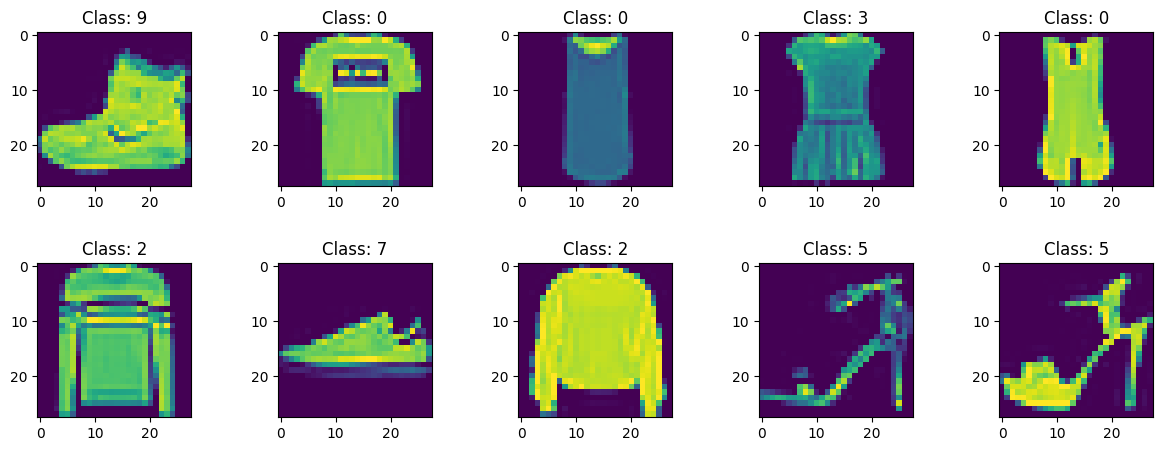

In [24]:
fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(15,5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(fm_X_train[i].reshape(28,28))
  ax[i].title.set_text('Class: ' + str(fm_y_train[i])) # Corrected string concatenation and variable
plt.subplots_adjust(hspace=0.5) # Corrected typo
plt.show()

##3.5. Xây dựng mô hình học ANN

In [26]:
fashion_model = Sequential()

fashion_model.add(Dense(input_dim=fm_X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

##3.6. Huấn luyện ANN model

In [28]:
model_fit = fashion_model.fit(fm_X_train, fm_y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8209 - loss: 0.5074 - val_accuracy: 0.8578 - val_loss: 0.3943
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8666 - loss: 0.3708 - val_accuracy: 0.8565 - val_loss: 0.3932
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8784 - loss: 0.3311 - val_accuracy: 0.8767 - val_loss: 0.3424
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8873 - loss: 0.3058 - val_accuracy: 0.8740 - val_loss: 0.3434
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8929 - loss: 0.2889 - val_accuracy: 0.8872 - val_loss: 0.3143
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8990 - loss: 0.2731 - val_accuracy: 0.8870 - val_loss: 0.3137
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9045 - loss: 0.2597 - val_accuracy: 0.8820 - val_loss: 0.3408
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9069 - loss: 0

##3.7. Đánh giá ANN model

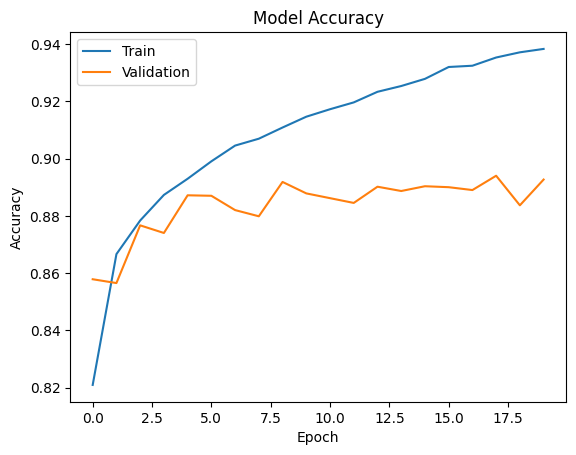

In [29]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

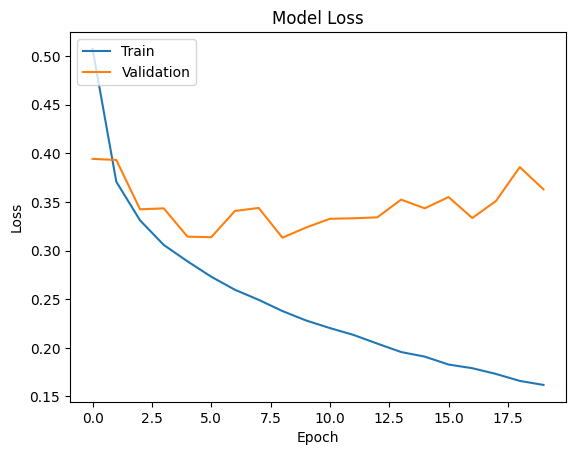

In [42]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

##3.8. Dự báo ảnh mới

In [32]:
print(np.argmax(fashion_model.predict(fm_X_test)[0]),fm_y_test[0])
print(np.argmax(fashion_model.predict(fm_X_test)[10]), fm_y_test[10])


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
4 4


#4. BÀI TẬP

##1. Viết chương trình cài đặt ANN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow
với các nhãn sau

Kich thuoc tap Train: (50000, 32, 32, 3)
Kich thuoc tap test: (10000, 32, 32, 3)


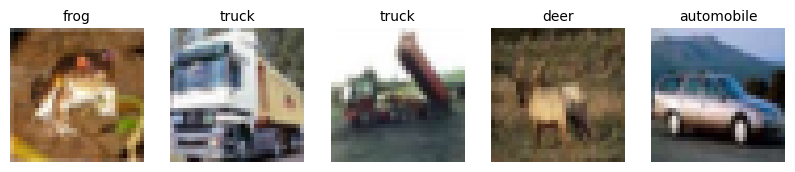

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.3149 - loss: 1.8891 - val_accuracy: 0.3628 - val_loss: 1.7670
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.3911 - loss: 1.6906 - val_accuracy: 0.3952 - val_loss: 1.6711
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.4216 - loss: 1.6169 - val_accuracy: 0.4210 - val_loss: 1.6172
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4424 - loss: 1.5594 - val_accuracy: 0.4196 - val_loss: 1.6108
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4580 - loss: 1.5242 - val_accuracy: 0.4582 - val_loss: 1.5284
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4698 - loss: 1.4904 - val_accuracy: 0.4552 - val_loss: 1.5367
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4813 - loss: 1.4583 - val_accuracy: 0.4634 - val_loss: 1.5131
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4838 - loss: 1.4442 - 

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import Adam

cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

class_names =['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
print('Kich thuoc tap Train:',X_train.shape)
print('Kich thuoc tap test:',X_test.shape)

plt.figure(figsize=(10,2))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(X_train[i])
  plt.title(class_names[y_train[i][0]],fontsize=10)
  plt.axis('off')
plt.show()

model = Sequential()

model.add(Flatten(input_shape=(32, 32, 3)))
model.add(Dense(units=256, activation='relu'))
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=10, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.1, verbose=1)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"\nĐộ chính xác trên tập Test: {test_acc*100:.2f}%")

prediction = model.predict(X_test[:1])
predicted_class = np.argmax(prediction)
true_class = y_test[0][0]

print(f"\nKết quả dự đoán ảnh đầu tiên: {class_names[predicted_class]}")
print(f"Nhãn thực tế của ảnh đầu tiên: {class_names[true_class]}")